# ML Uppgift 1 Housing Project
## Spår A - Regression  (förutsäga bostadsvärde)

In [1]:
import sys
print(sys.version)

3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.decomposition import PCA  

In [3]:
df = pd.read_csv("housing.csv")
print("shape:", df.shape)
df.head()

shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Data & EDA (kort data-insikt)

I detta avsnitt analyseras datasetets struktur, datatyper och saknade värden.
Syftet är att skapa en grundläggande förståelse för datan inför modellering.

### Datasetets storlek

Datasetet består av 20 640 rader (observationer) och 10 kolumner (variabler).
Detta ger tillräckligt med data för att träna och utvärdera en regressionsmodell.

In [4]:
display(df.dtypes)
print("\nKolumner:")
print(list(df.columns))

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object


Kolumner:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


### Saknade värden

Här undersöks om datasetet innehåller saknade värden.
Saknade värden behöver hanteras i pipelinen innan modellträning.

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
display(missing)

total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Det finns 207 saknade värden i kolumnen `total_bedrooms`.
Övriga variabler saknar saknade värden.
Dessa kommer att hanteras i pipelinen med imputering (medianvärde).

### Fördelning av target-variabeln

Nedan visas fördelningen av `median_house_value`.

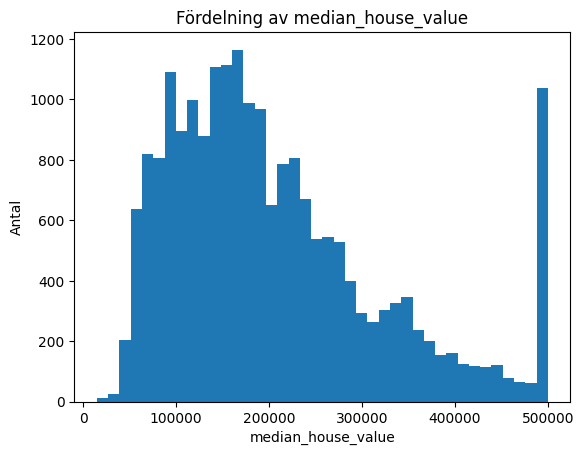

In [6]:
fig, ax = plt.subplots()

ax.hist(df["median_house_value"], bins=40)
ax.set_title("Fördelning av median_house_value")
ax.set_xlabel("median_house_value")
ax.set_ylabel("Antal")

plt.show()

### Geografisk spridning

Nedan visas hur observationerna är fördelade geografiskt med longitude och latitude.

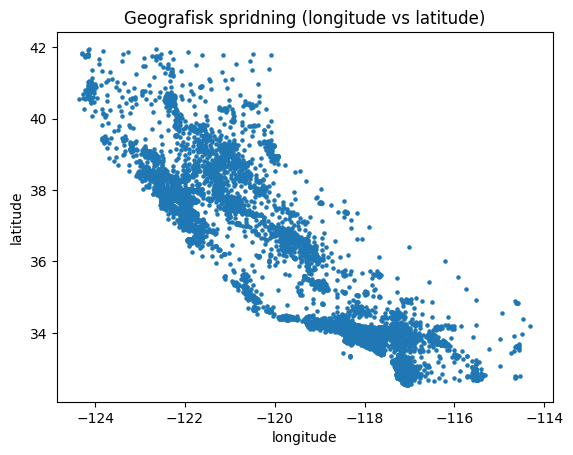

In [7]:
fig, ax = plt.subplots()

ax.scatter(df["longitude"], df["latitude"], s=5)
ax.set_title("Geografisk spridning (longitude vs latitude)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")

plt.show()

- Fördelningen av `median_house_value` visar en viss högerskevhet.
- Observationerna är geografiskt koncentrerade i vissa områden, särskilt längs Kaliforniens kust.
- Detta tyder på att geografisk position kan vara en relevant faktor vid   modellering av bostadsvärde.

Target-variabeln som ska förutsägas är `median_house_value`.

In [8]:
target = "median_house_value"

y = df[target].copy()
X = df.drop(columns=[target]).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 9)
y shape: (20640,)


### Train/Test-split

Datan delas upp i träningsdata (80%) och testdata (20%).
Testdatan används endast för slutlig utvärdering.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (16512, 9)
X_test: (4128, 9)


### Preprocessing (utan leakage)

Preprocessing görs i en pipeline så att ingen information från testdatan påverkar träningen.
Numeriska variabler skalas och saknade värden imputeras.
Kategoriska variabler one-hot-encodas.

In [10]:
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeriska kolumner:", num_cols)
print("Kategoriska kolumner:", cat_cols)

Numeriska kolumner: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Kategoriska kolumner: ['ocean_proximity']


In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

### Modelljämförelse (baseline + 2 modeller)

Tre modeller jämförs:

- DummyRegressor som baseline.
- Ridge (linjär modell med regularisering).
- RandomForestRegressor (icke-linjär modell).

Utvärdering sker med 5-fold cross-validation och MAE.

In [12]:
models = {
    "Baseline (Dummy)": DummyRegressor(strategy="mean"),
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(random_state=SEED)
}

In [13]:
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error"
    )

    mae_mean = -scores.mean()
    mae_std = scores.std()

    results.append((name, mae_mean, mae_std))

cv_results = (
    pd.DataFrame(results, columns=["Model", "CV_MAE_Mean", "CV_MAE_Std"])
      .sort_values("CV_MAE_Mean")
)

cv_results

,Model,CV_MAE_Mean,CV_MAE_Std
2,RandomForest,32206.386933,523.774114
1,Ridge,49665.128165,779.278569
0,Baseline (Dummy),91394.674508,848.160631


### Hyperparameter-tuning (RandomForest)

RandomForest valdes eftersom den hade lägst MAE i cross-validation.
Modellen optimeras med GridSearchCV och utvärderas med MAE.

In [14]:

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=SEED))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_mae_cv = -grid.best_score_
best_params = grid.best_params_

print(f"Best MAE (CV): {best_mae_cv:.2f}")
print("Best parameters:", best_params)

Best MAE (CV): 32122.17
Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}


### Slutlig utvärdering på testdata

Den optimerade modellen utvärderas på testdatan.
MAE och RMSE rapporteras.

In [15]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred)
rmse_test = mean_squared_error(y_test, y_pred) ** 0.5  

print(f"Test MAE: {mae_test:.2f}")
print(f"Test RMSE: {rmse_test:.2f}")

Test MAE: 31465.25
Test RMSE: 48781.91


### PCA-analys

PCA används för att undersöka om de numeriska variablerna kan sammanfattas
i färre dimensioner.

Analysen görs endast på numeriska variabler och efter standardisering.

In [16]:
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_num = X[num_cols].copy()

imputer = SimpleImputer(strategy="median")
X_num_imputed = imputer.fit_transform(X_num)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num_imputed)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print("Förklarad varians per komponent:")
print(pca.explained_variance_ratio_)

Förklarad varians per komponent:
[0.48755031 0.2384736 ]


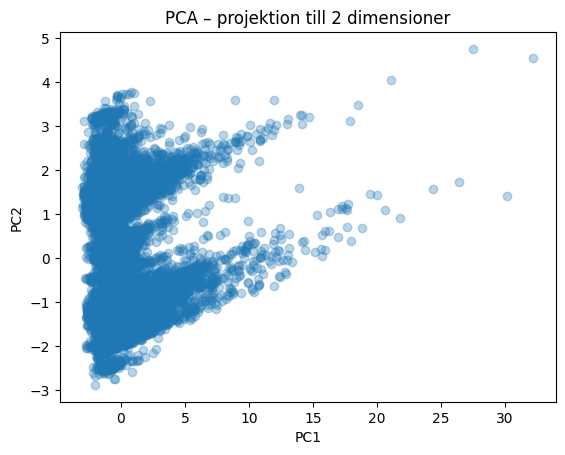

In [17]:
fig, ax = plt.subplots()
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA – projektion till 2 dimensioner")
plt.show()

### Tolkning av PCA

De två första huvudkomponenterna förklarar cirka 72 % av variationen i de numeriska variablerna.

Detta innebär att en stor del av informationen i datan kan sammanfattas 
i två dimensioner, men inte all variation fångas.

Spridningen i figuren visar att datan har viss struktur och klusterliknande 
mönster, vilket kan indikera att vissa områden eller bostadstyper skiljer sig 
åt.

Osäkerhet:
- PCA fångar endast linjära samband.
- Tolkningen av komponenterna är inte direkt intuitiv.
- Informationsförlust sker när dimensionerna reduceras.

### Slutsats

Målet med projektet var att förutsäga bostadsvärdet (`median_house_value`)
med hjälp av variabler i datasetet.

Efter att ha jämfört flera modeller presterade RandomForest bäst.
Efter optimering fick modellen en test-MAE på cirka 31 000 och en
RMSE på cirka 48 800.

Detta visar att modellen kan göra rimliga prediktioner, men att det
fortfarande finns felmarginaler.

PCA-analysen visade att de två första komponenterna förklarar cirka
72 % av variationen i de numeriska variablerna. Det betyder att mycket
av informationen kan sammanfattas i färre dimensioner, men inte all.

Sammanfattningsvis fungerar modellen bra, men resultaten påverkas av
val av parametrar och hur datan är uppbyggd.

### Begränsningar

- Datasetet innehåller områdesdata och inte information om enskilda bostäder.
- Modellen påverkas av hur saknade värden hanteras.
- RandomForest är mindre tolkbar än en linjär modell.
- Resultaten kan variera beroende på val av parametrar och random seed.
- PCA fångar endast linjära samband och innebär viss informationsförlust.